# Лабораторная работа: Ансамбли моделей машинного обучения. Часть 1

**Цель работы:** Изучение ансамблевых моделей машинного обучения на примере датасета Wine.

## 1. Описание датасета и импорт необходимых библиотек

В данной работе используется встроенный датасет `load_wine` из библиотеки `scikit-learn`.  
Датасет содержит 178 образцов вин, каждый из которых характеризуется 13 числовыми признаками (содержание алкоголя, флавоноиды, интенсивность цвета и т.д.).  
Целевая переменная представляет собой сорт вина:
*   `0` — сорт 0
*   `1` — сорт 1
*   `2` — сорт 2

Датасет не содержит пропущенных значений и категориальных признаков, поэтому этап предобработки сводится только к разделению на обучающую и тестовую выборки.

In [1]:
import numpy as np
import pandas as pd

# Импорт датасетов и функций sklearn
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# Импорт метрик
from sklearn.metrics import f1_score

# Импорт моделей
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

# Импорт визуализаций
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

from operator import itemgetter

print("Библиотеки успешно импортированы!")

Библиотеки успешно импортированы!


## 2. Загрузка и исследование датасета

Загружаем данные и создаем DataFrame для удобства анализа. Проверим размерность, отсутствие пропусков и посмотрим на баланс классов.

In [2]:
wine = load_wine()
X = wine.data
y = wine.target

# Создаем DataFrame для визуального анализа
df = pd.DataFrame(data=X, columns=wine.feature_names)
df['target'] = y

print("Размерность матрицы признаков:", X.shape)
print("Количество классов:", len(wine.target_names))
print("Названия классов:", wine.target_names)
print("\nИнформация о датасете:")
df.info()

Размерность матрицы признаков: (178, 13)
Количество классов: 3
Названия классов: ['class_0' 'class_1' 'class_2']

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null   

Распределение классов:
 target
1    71
0    59
2    48
Name: count, dtype: int64


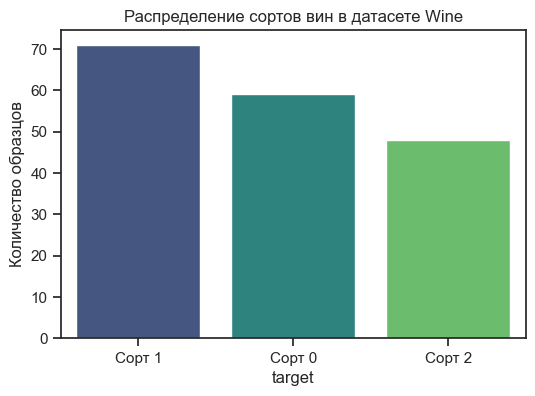

In [3]:
class_counts = df['target'].value_counts()
class_names_mapped = class_counts.index.map({0: 'Сорт 0', 1: 'Сорт 1', 2: 'Сорт 2'})

print("Распределение классов:\n", class_counts)

plt.figure(figsize=(6, 4))
sns.barplot(
    x=class_names_mapped, 
    y=class_counts.values, 
    hue=class_names_mapped,   
    legend=False,             
    palette="viridis"
)
plt.title('Распределение сортов вин в датасете Wine')
plt.ylabel('Количество образцов')
plt.show()

## 3. Разделение на обучающую и тестовую выборки

С помощью `train_test_split` разделим данные в соотношении 70/30.  
Параметр `stratify=y` гарантирует сохранение пропорций классов в обучающей и тестовой выборках.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nБаланс классов в обучающей выборке:\n{pd.Series(y_train).value_counts()}")
print(f"\nБаланс классов в тестовой выборке:\n{pd.Series(y_test).value_counts()}")

Размер обучающей выборки: (124, 13)
Размер тестовой выборки: (54, 13)

Баланс классов в обучающей выборке:
1    50
0    41
2    33
Name: count, dtype: int64

Баланс классов в тестовой выборке:
1    21
0    18
2    15
Name: count, dtype: int64


## 4. Обучение ансамблевых моделей

Мы обучим четыре модели в соответствии с заданием:
1.  **Random Forest (Случайный лес)** — метод бэггинга со случайным выбором признаков.
2.  **Extra Trees (Сверхслучайные деревья)** — метод бэггинга с еще большей рандомизацией.
3.  **AdaBoost** — метод бустинга, адаптивно взвешивающий слабые модели.
4.  **Gradient Boosting (Градиентный бустинг)** — метод бустинга, оптимизирующий функцию потерь.

Для воспроизводимости результатов во всех моделях зафиксирован `random_state`.

In [5]:
models = {}

# Модели группы бэггинга
models['Random Forest'] = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)

models['Extra Trees'] = ExtraTreesClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)

# Модели группы бустинга
models['AdaBoost'] = AdaBoostClassifier(
    n_estimators=100, random_state=42
)

models['Gradient Boosting'] = GradientBoostingClassifier(
    n_estimators=100, random_state=42
)

# Обучение всех моделей
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Модель '{name}' успешно обучена.")

print("\nВсе модели обучены!")

Модель 'Random Forest' успешно обучена.
Модель 'Extra Trees' успешно обучена.
Модель 'AdaBoost' успешно обучена.
Модель 'Gradient Boosting' успешно обучена.

Все модели обучены!


## 5. Оценка качества моделей

Для оценки качества моделей будем использовать метрику **F1-Score (macro)**.

**Обоснование выбора метрики:**  
Датасет Wine содержит три класса вин. Для многоклассовой классификации F1-Score с усреднением `macro` является хорошим выбором, так как:
*   Он вычисляет F1-Score для каждого класса отдельно и берет среднее арифметическое.
*   Все классы считаются одинаково важными, независимо от их размера.
*   Это позволяет объективно оценить способность модели различать все три сорта вин.

Также F1-Score учитывает качество классификации для каждого класса отдельно.

В датасете Wine классы распределены следующим образом:
- Сорт 0: 59 образцов
- Сорт 1: 71 образец
- Сорт 2: 48 образцов

При использовании `average='weighted'` больший вес получают многочисленные классы (сорт 1), и модель может "проигнорировать" редкий класс (сорт 2), сохранив высокую метрику. Усреднение `macro` считает все классы одинаково важными, вычисляя F1-Score для каждого класса и беря среднее арифметическое:


Сравним качество всех моделей на тестовой выборке по метрике F1-Score (macro).

Сравнение моделей по метрике F1-Score (macro):

Модель                    F1-Score  
Random Forest             1.0000    
Extra Trees               1.0000    
AdaBoost                  0.9811    
Gradient Boosting         0.9652    


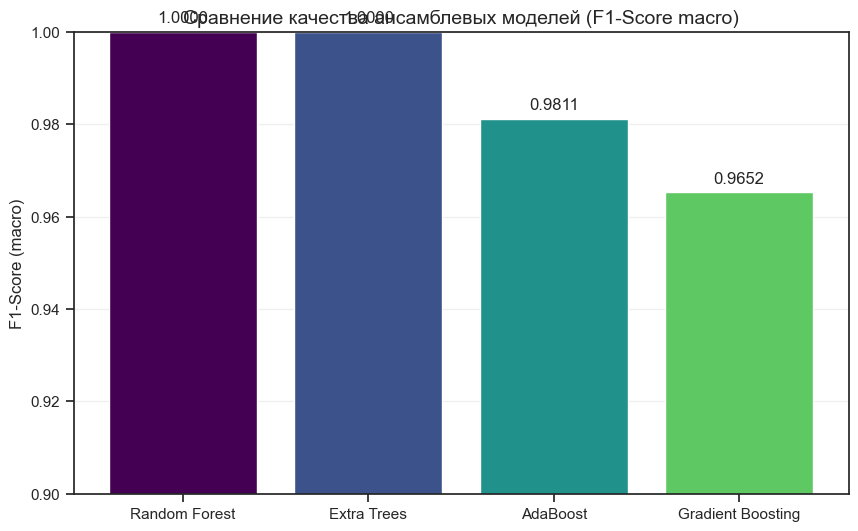


Лучшая модель: Random Forest (F1 = 1.0000)


In [6]:
print("Сравнение моделей по метрике F1-Score (macro):\n")
print(f"{'Модель':<25} {'F1-Score':<10}")

f1_scores = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    f1_scores[name] = f1
    print(f"{name:<25} {f1:<10.4f}")

# Построение графика сравнения
plt.figure(figsize=(10, 6))
bars = plt.bar(f1_scores.keys(), f1_scores.values(), color=['#440154', '#3b528b', '#21918c', '#5ec962'])
plt.title('Сравнение качества ансамблевых моделей (F1-Score macro)', fontsize=14)
plt.ylabel('F1-Score (macro)', fontsize=12)
plt.ylim(0.90, 1.0)
plt.grid(axis='y', alpha=0.3)

for bar, score in zip(bars, f1_scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f'{score:.4f}', ha='center', fontsize=12)

plt.show()

print(f"\nЛучшая модель: {max(f1_scores, key=f1_scores.get)} (F1 = {max(f1_scores.values()):.4f})")

## 6. Выводы по работе

**Основные результаты:**

| Место | Модель | F1-Score (macro) |
|-------|--------|------------------|
| 1 | Random Forest | 1.0000 |
| 1 | Extra Trees | 1.0000 |
| 3 | AdaBoost | 0.9811 |
| 4 | Gradient Boosting | 0.9652 |

**Анализ результатов:**

*   **Модели Random Forest и Extra Trees достигли идеального качества (F1 = 1.0000)**, безошибочно классифицировав все три сорта вин на тестовой выборке. Это объясняется хорошей разделимостью классов в датасете Wine и способностью бэггинг-методов эффективно работать с небольшим количеством признаков (13).
*   **AdaBoost** показал близкий к идеальному результат (F1 = 0.9811).
*   **Gradient Boosting** набрал наименьший балл (F1 = 0.9652) среди всех моделей. Это может быть связано с тем, что для маленького датасета (124 обучающих объекта) градиентный бустинг склонен к переобучению.

**Вывод:**

Все ансамблевые методы успешно справились с задачей классификации вин. Random Forest и Extra Trees продемонстрировали идеальное качество, что подтверждает эффективность бэггинг-подхода на небольших хорошо разделимых датасетах. Модели бустинга показали немного худшие результаты из-за склонности к переобучению при малом размере выборки. Для повышения качества Gradient Boosting рекомендуется уменьшить скорость обучения (`learning_rate`) и увеличить количество деревьев.